In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

from hubble_fit import *

In [2]:

# Load Pantheon+ SN metadata
print("Loading Pantheon+ supernova data...")
df_pantheon = pd.read_csv(
    #"https://raw.githubusercontent.com/PantheonPlusSH0ES/DataRelease/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES.dat",
    "data/Pantheon+SH0ES.dat",
    sep=r"\s+"
)

print("Loading SN covariance matrix...")
n_sn = len(df_pantheon)

# Load .cov file with NumPy, skipping the first line (which contains just "1701")
cov_flat = np.loadtxt(
    #"https://raw.githubusercontent.com/PantheonPlusSH0ES/DataRelease/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES_STAT%2BSYS.cov",
    "data/Pantheon+SH0ES_STAT+SYS.cov",
    skiprows=1
)

# Reshape into square matrix
cov_matrix = cov_flat.reshape((n_sn, n_sn))

# Confirm shape is correct
assert cov_matrix.shape == (n_sn, n_sn), f"Expected ({n_sn},{n_sn}), got {cov_matrix.shape}"

# Invert covariance and pre-compute log-determinant for SN likelihood
global Cov_inv, logdetCov
Cov_inv = np.linalg.inv(cov_matrix)
sign, logdet = np.linalg.slogdet(cov_matrix)
if sign <= 0:
    raise ValueError("Covariance matrix is not positive-definite!")
logdetCov = logdet
print("Data loaded. Running joint cosmographic fits...")


Loading Pantheon+ supernova data...
Loading SN covariance matrix...
Data loaded. Running joint cosmographic fits...


In [3]:
print("Loading quasar data...")
df_agn = load_quasar_data("data/N20_w500_grace/may21_joint_fits_N20_merged.h5")

#df_agn_f = df_agn.sample(n=100, random_state=42).reset_index(drop=True)

Loading quasar data...


Reading quasars from HDF5:   0%|          | 0/100 [00:00<?, ?it/s]

Reading quasars from HDF5: 100%|██████████| 100/100 [00:00<00:00, 1211.69it/s]

Populating SDSS fields: 100


Number of quasars loaded: 100
Columns with NaNs: []
Number of quasars with 0 < z <= 1: 15
Number of quasars with z > 3: 5
Final number of quasars: 100


In [21]:
cosmo_model = 'Flatw0waCDM'
sampler_joint, _ = run_mcmc_pipeline(df_agn, df_pantheon, cosmo_model=cosmo_model, only_sna=False, completeness=True, use_full_cov=False,
                                     num_warmup=500, num_samples=150)

100%|██████████| 150/150 [00:35<00:00,  4.27it/s]


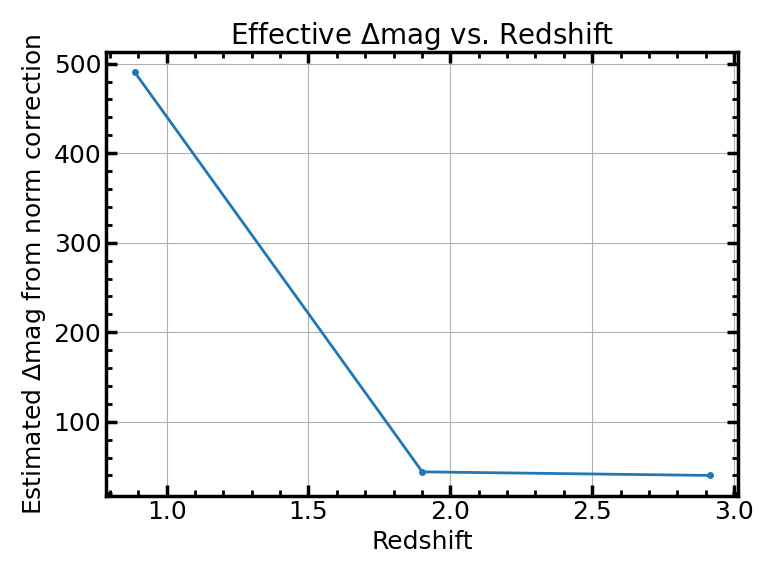

In [31]:
# Evaluate log_likelihood at the posterior median parameters
flat_samples = sampler_joint.get_chain(discard=0, thin=1, flat=True)
median_theta = np.median(flat_samples, axis=0)
completeness_params = get_completeness_function_2d(df_agn)
p_detect, mag_centers, z_centers, dm, dz = completeness_params
ll, norm_correction, m_model = log_likelihood(
    median_theta, cosmo_model,
    df_agn, df_pantheon, completeness_params,
    only_sna=False, use_full_cov=False,
    return_params=True
)

#print(f"Log-likelihood at posterior median parameters: {ll_median:.3f}")

import numpy as np
import matplotlib.pyplot as plt

# Choose redshift bins
z = df_agn['z'].values
z_bins = np.linspace(np.min(z), np.max(z), 4)
z_centers = 0.5 * (z_bins[:-1] + z_bins[1:])
delta_mag_arr = []

for i in range(len(z_bins) - 1):
    in_bin = (z >= z_bins[i]) & (z < z_bins[i+1])
    if not np.any(in_bin):
        delta_mag_arr.append(np.nan)
        continue

    m_bin = m_model[in_bin]
    z_bin = z[in_bin]
    N_bin = np.sum(in_bin)
    if N_bin < 3:
        delta_mag_arr.append(np.nan)
        continue

    mean_mag = np.mean(m_bin)
    z_typical = np.median(z_bin)
    dm = 0.01
    p1 = p_detect(mean_mag, z_typical)
    p2 = p_detect(mean_mag + dm, z_typical)
    alpha = - (np.log(p2) - np.log(p1)) / dm

    # Compute norm_correction for this bin
    # (If you have per-object norm_correction, sum those; otherwise, scale global norm_correction by N_bin/N)
    norm_correction_bin = norm_correction * (N_bin / len(m_model))
    delta_mag = -norm_correction_bin / (N_bin * alpha)
    delta_mag_arr.append(delta_mag)

plt.figure(figsize=(8,6))
plt.plot(z_centers, delta_mag_arr, marker='o')
plt.xlabel("Redshift")
plt.ylabel(r"Estimated $\Delta$mag from norm correction")
plt.title(r"Effective $\Delta$mag vs. Redshift")
plt.grid(True)
plt.tight_layout()
plt.show()

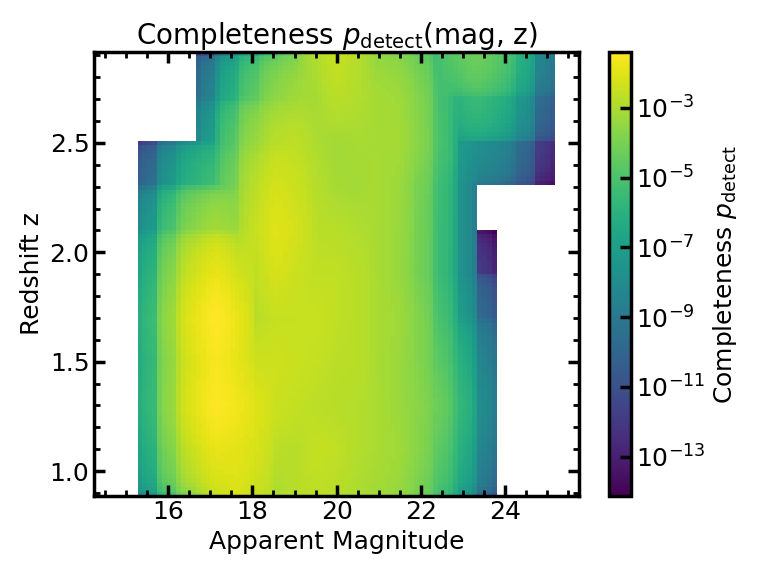

In [43]:
from matplotlib.colors import LogNorm

plt.figure(figsize=(8, 6))
im = plt.imshow(
    p_grid,
    extent=[mag_grid[0], mag_grid[-1], z_grid[0], z_grid[-1]],
    aspect='auto',
    origin='lower',
    cmap='viridis',
    norm=LogNorm(vmin=np.nanmin(p_grid[p_grid > 0]), vmax=np.nanmax(p_grid))
)
plt.colorbar(im, label='Completeness $p_{\\rm detect}$')
plt.xlabel('Apparent Magnitude')
plt.ylabel('Redshift z')
plt.title('Completeness $p_{\\rm detect}$(mag, z)')
plt.tight_layout()
plt.show()


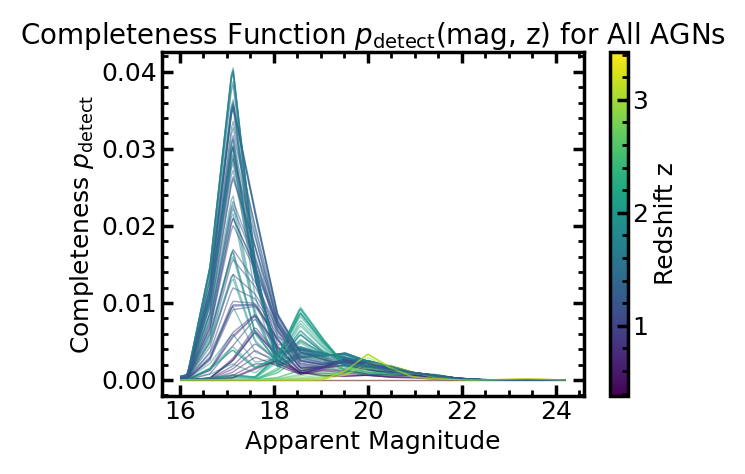

In [41]:
import numpy as np
import matplotlib.pyplot as plt

def plot_p_detect_for_all_agns(df_agn, p_detect, mag_range=None, n_mag=200, cmap='viridis'):
    mags_agn = df_agn['apparent_mag_i'].values
    zs_agn = df_agn['z'].values

    if mag_range is None:
        min_mag = np.min(mags_agn) - 1
        max_mag = np.max(mags_agn) + 1
    else:
        min_mag, max_mag = mag_range

    mag_grid = np.linspace(min_mag, max_mag, n_mag)
    norm = plt.Normalize(np.min(zs_agn), np.max(zs_agn))
    cmap = plt.get_cmap(cmap)

    fig, ax = plt.subplots(figsize=(7, 5))
    for mag_i, z_i in zip(mags_agn, zs_agn):
        z_arr = np.full_like(mag_grid, z_i, dtype=float)
        p_vals = p_detect(mag_grid, z_arr)
        ax.plot(mag_grid, p_vals, color=cmap(norm(z_i)), alpha=0.5, lw=1)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label='Redshift z')
    ax.set_xlabel('Apparent Magnitude')
    ax.set_ylabel('Completeness $p_{\\rm detect}$')
    ax.set_title('Completeness Function $p_{\\rm detect}$(mag, z) for All AGNs')
    fig.tight_layout()
    plt.show()

plot_p_detect_for_all_agns(df_agn, p_detect)


/home/dutra/dev/eztaox/venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/dutra/dev/eztaox/venv/lib/python3.13/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/dutra/dev/eztaox/venv/lib/python3.13/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/dutra/dev/eztaox/venv/lib/python3.13/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/dutra/dev/eztaox/venv/lib/python3.13/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/dutra/dev/eztaox/tutorials/hubble_plotting.py:258: UserWarning: 

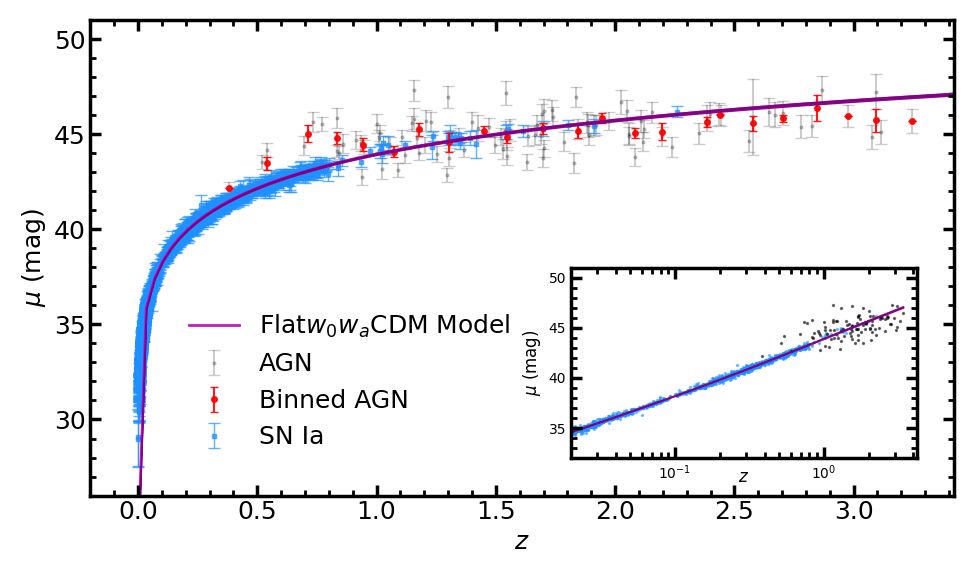

(array([-1.23033032,  2.24356282,  0.51926751, -1.08061581, -0.59069505,
        -0.40576318, -1.28417648, -1.99738203, -0.4943677 , -0.13974363,
         1.26680514,  0.97451557,  1.27542112, -0.61014244, -1.18509602,
        -0.26194466,  0.63473525, -1.75368744,  0.42576288, -0.15784844,
         2.34700267,  0.08407239, -0.3385867 , -0.65944045, -0.55930904,
         0.66598057, -0.35594397, -0.27398747,  0.04883802, -0.27324664,
         0.00432496, -1.18076031,  0.21674807,  0.17654082,  0.88224406,
         1.08140749, -2.03439035,  0.40133386, -0.18193822,  0.75458235,
         2.30479495,  0.92806406, -1.72230159,  0.29527949,  0.0360516 ,
        -1.57316281,  0.60635175, -0.31948059, -2.03979262,  0.5151664 ,
         0.75810114,  0.81268321,  0.93805748,  0.10603466,  1.37351507,
        -0.84597067,  0.43495416,  1.59013955, -0.44682601, -0.83842922,
        -0.55392846,  0.15335147, -0.11584858,  0.82563384, -0.15777631,
        -0.32826235, -0.14837452,  0.49494106, -0.3

In [5]:
plot_hubble(sampler_joint, df_agn, df_pantheon, cosmo_model=cosmo_model, show=True)

Generating corner plot: 100%|██████████| 4/4 [00:22<00:00,  5.51s/it]


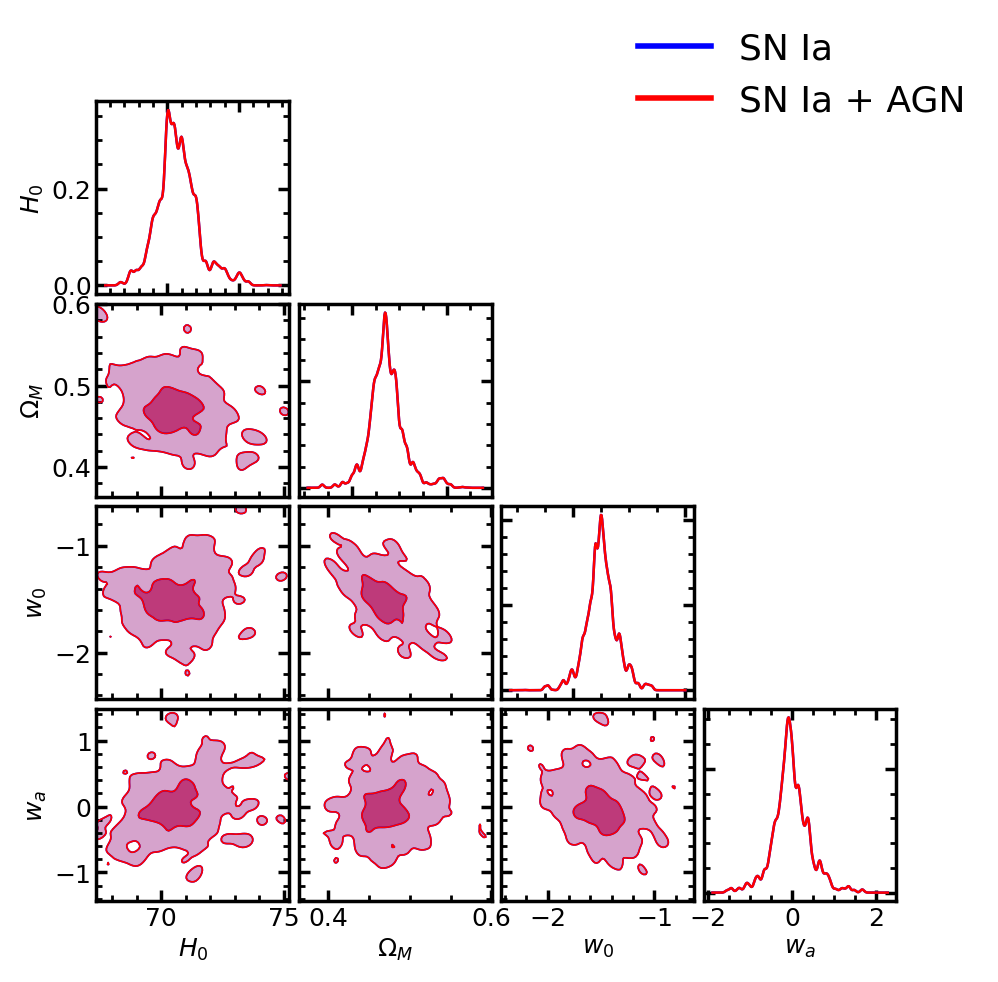

In [6]:
plot_cosmo_corner(sampler_joint, sampler_joint, cosmo_model=cosmo_model, show=True)

In [8]:
from scipy.stats import linregress

from hubble_plotting import plot_predicted_sigma_hat_vs_luminosity
plot_predicted_sigma_hat_vs_luminosity(sampler_joint, df_agn, cosmo_model=cosmo_model, show=True)
#plot_predicted_vs_actual_loglbol(sampler_joint, df_agn, cosmo_model=cosmo_model, show=True)

ValueError: operands could not be broadcast together with shapes (3,) (100,) 

In [15]:
quasar_list = read_quasars_from_hdf5("data/may8_lc_all.h5")


Reading quasars from HDF5: 100%|██████████| 38825/38825 [02:20<00:00, 275.41it/s]


In [16]:
df_agn = pd.DataFrame(quasar_list)

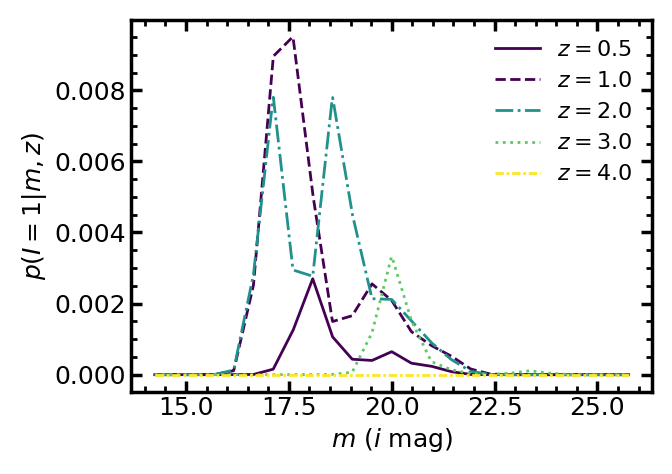

In [9]:
from hubble_utils import *
from hubble_plotting import *

#df_agn = load_quasar_data()
p_detect, mag_centers, z_centers, dm, dz = get_completeness_function_2d(df_agn)
plot_completeness_vs_mag_at_redshifts(p_detect, mag_centers, z_centers, show=True)

In [ ]:
# Estimate the local slope of ln p(m) near the mean magnitude

mean_mag = np.mean(m_model)
# Evaluate p_detect at mean_mag for a typical z
z_typical = np.median(z)
dm = 0.01
p1 = p_detect(mean_mag, z_typical)
p2 = p_detect(mean_mag + dm, z_typical)
alpha = - (np.log(p2) - np.log(p1)) / dm

# Estimate delta mag
N = len(m_model)
delta_mag = -norm_correction / (N * alpha)
print(f"Estimated Δmag from norm_correction: {delta_mag:.3f} mag")